In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [11]:
# =============================================================
# LOAD DATA
# =============================================================
df_fights = pd.read_csv('data.csv', encoding='latin1')
df_details = pd.read_csv('raw_fighter_details.csv', encoding='latin1')

print("Data loaded successfully.")
print(f"Total number of fights: {len(df_fights)}")
print(f"Total number of fighters (in details table): {len(df_details)}")

Data loaded successfully.
Total number of fights: 6012
Total number of fighters (in details table): 3596


In [12]:
# =============================================================
# DATA ENRICHMENT — ADDING EXPERIENCE LEVEL
# =============================================================
# We count how many times each fighter appears in the dataset.
# If a fighter has more than 10 fights, they are labeled 'Veteran'.
# Everyone else is labeled 'Prospect'.
# This new column (Experience_Level) will be our target variable
# in the Machine Learning phase, representing long-term career success.

all_fighters = pd.concat([df_fights['R_fighter'], df_fights['B_fighter']])
experience_counts = all_fighters.value_counts().reset_index()
experience_counts.columns = ['fighter_name', 'total_fights']

experience_counts['Experience_Level'] = experience_counts['total_fights'].apply(
    lambda x: 'Veteran' if x > 10 else 'Prospect'
)

df_details = df_details.merge(experience_counts, on='fighter_name', how='left')
print("Enrichment complete: Experience levels have been added.")

# OUTPUT — Enrichment:
# The dataset now has an Experience_Level column for each fighter.
# Veterans (327 fighters, 15.3%) had more than 10 career fights.
# Prospects (1,812 fighters, 84.7%) had 10 or fewer fights.
# This column will be used as the target variable in the ML phase.

Enrichment complete: Experience levels have been added.


In [13]:
# =============================================================
# DATA CLEANING FOR ANALYSIS
# =============================================================
# We only keep the columns we need for the hypothesis test.
# Rows with missing values are removed so the t-test is clean.
# We also create a binary column: 1 if Blue corner wins, 0 otherwise.
# This lets us compare win rates as numbers.

df_clean = df_fights[['Winner', 'B_avg_TD_pct', 'B_avg_SIG_STR_pct']].dropna().copy()
df_clean['is_Blue_Winner'] = df_clean['Winner'].apply(lambda x: 1 if x == 'Blue' else 0)
print(f"\nUsable fights after cleaning: {len(df_clean)}")

# =============================================================
# SUMMARY STATISTICS (EDA)
# =============================================================
 
print("\nSummary Statistics")
print(df_clean.describe())
 
# OUTPUT — Summary Statistics:
# Takedown accuracy mean is ~0.29, so fighters land about 29%
# of their takedown attempts on average.
# Striking accuracy mean is ~0.45, which is higher and more consistent.
# Blue corner wins about 33.5% of fights in this dataset.
# These numbers give us a baseline before we start comparing groups.


Usable fights after cleaning: 4585

Summary Statistics
       B_avg_TD_pct  B_avg_SIG_STR_pct  is_Blue_Winner
count   4585.000000        4585.000000     4585.000000
mean       0.292650           0.453310        0.335224
std        0.273628           0.130458        0.472120
min        0.000000           0.000000        0.000000
25%        0.031250           0.376489        0.000000
50%        0.250000           0.450000        0.000000
75%        0.500000           0.527500        1.000000
max        1.000000           1.000000        1.000000


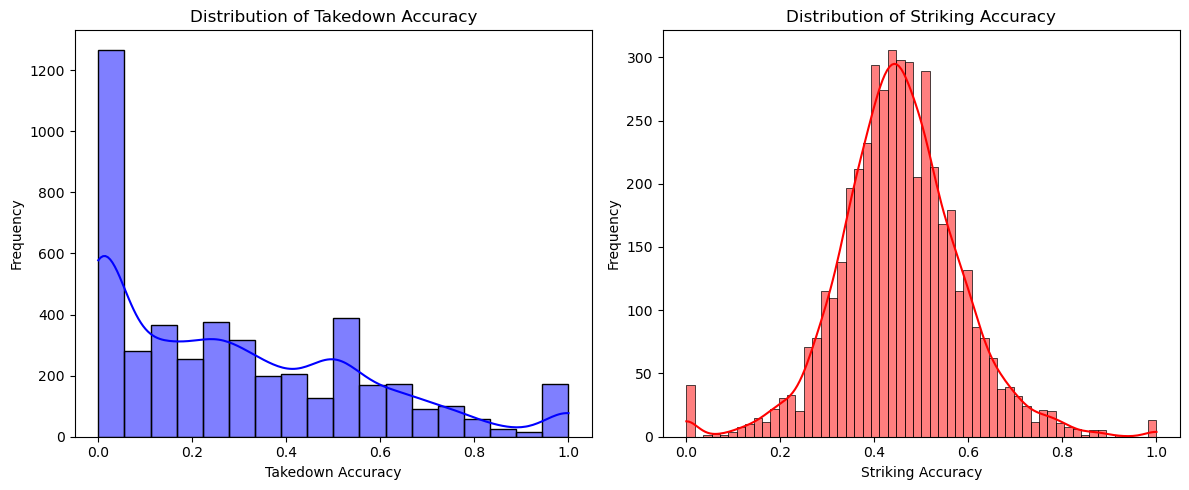

In [14]:
# =============================================================
# VISUALIZATION 1 — DISTRIBUTION PLOTS
# =============================================================
# We plot the distributions of takedown accuracy and striking accuracy
# to understand their shapes before running statistical tests.
# This helps us decide which test is appropriate.

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['B_avg_TD_pct'], kde=True, color='blue')
plt.title('Distribution of Takedown Accuracy')
plt.xlabel('Takedown Accuracy')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df_clean['B_avg_SIG_STR_pct'], kde=True, color='red')
plt.title('Distribution of Striking Accuracy')
plt.xlabel('Striking Accuracy')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# OUTPUT — Distribution Plots:
# Takedown accuracy is heavily right-skewed with a large spike at 0.
# Many fighters either never attempt takedowns or rarely land them.
# Striking accuracy is more bell-shaped, centered around 0.40-0.45.
# The two metrics have very different shapes, which means they capture
# fundamentally different aspects of a fighter's style.
# This difference justifies treating them separately in our analysis.

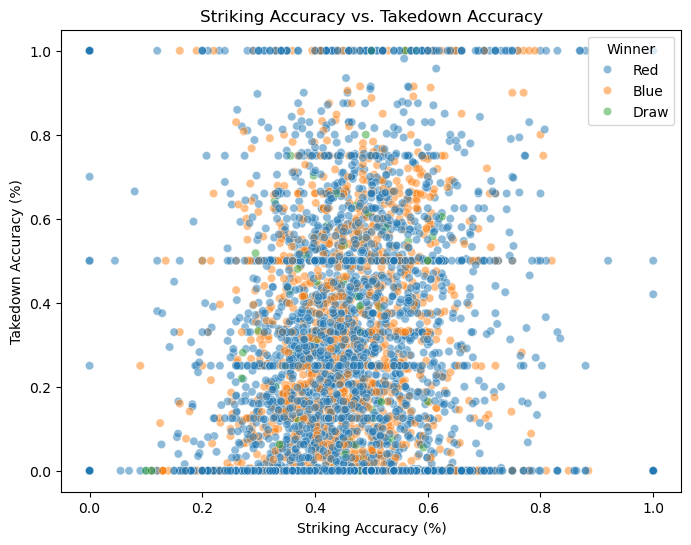

In [15]:
# =============================================================
# VISUALIZATION 2 — SCATTER PLOT
# =============================================================
# This scatter plot examines the joint relationship between striking
# accuracy and takedown accuracy, colored by the fight winner.
# If one combat style strongly predicts the winner, we would expect
# clear color separation along one of the axes.

plt.figure(figsize=(8, 6))
sns.scatterplot(x='B_avg_SIG_STR_pct', y='B_avg_TD_pct', hue='Winner', data=df_clean, alpha=0.5)
plt.title('Striking Accuracy vs. Takedown Accuracy')
plt.xlabel('Striking Accuracy (%)')
plt.ylabel('Takedown Accuracy (%)')
plt.show()


# OUTPUT — Scatter Plot:
# The three colors (Red, Blue, Draw) are completely mixed across the plot.
# No area belongs clearly to one winner type.
# This shows that neither striking nor takedown accuracy alone
# can predict who wins a fight.
# A more complex, multi-feature model is needed — which is why
# we move to machine learning in the next phase.

C:\Users\merte\AppData\Local\Temp\ipykernel_9212\2645608820.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Experience_Level', data=df_details, palette='viridis')


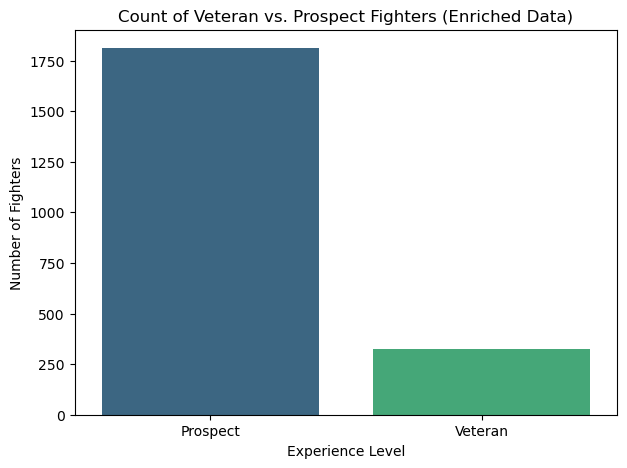

In [16]:
# =============================================================
# VISUALIZATION 3 — EXPERIENCE LEVEL COUNT
# =============================================================
# This bar chart shows how many Veteran and Prospect fighters
# are in our enriched dataset. We need to check this because
# a big imbalance can cause problems in machine learning.

plt.figure(figsize=(7, 5))
sns.countplot(x='Experience_Level', data=df_details, palette='viridis')
plt.title('Count of Veteran vs. Prospect Fighters (Enriched Data)')
plt.xlabel('Experience Level')
plt.ylabel('Number of Fighters')
plt.show()

# OUTPUT — Experience Level Count:
# The chart confirms a large class imbalance: 1,812 Prospects vs 327 Veterans.
# About 85% of fighters are Prospects, only 15% are Veterans.
# This reflects the real world — most UFC fighters compete only a few times.
# This imbalance must be handled in ML, which is why we use
# class_weight='balanced' in both classifiers.

C:\Users\merte\AppData\Local\Temp\ipykernel_9212\1053952865.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Winner', y='B_avg_TD_pct', data=df_clean, palette='pastel')


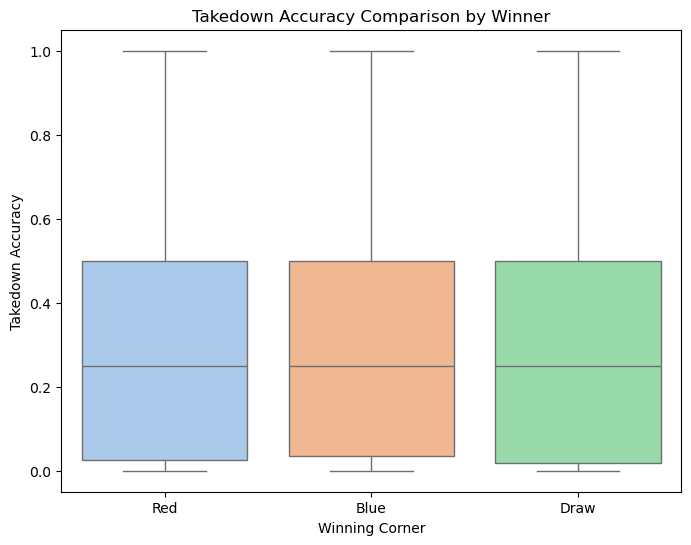

In [17]:
# =============================================================
# VISUALIZATION 4 — BOX PLOT
# =============================================================
# This plot compares takedown accuracy between winning corners.
# If grapplers win more, we expect the Blue winner box to be
# noticeably higher than the Red winner box.

plt.figure(figsize=(8, 6))
sns.boxplot(x='Winner', y='B_avg_TD_pct', data=df_clean, palette='pastel')
plt.title('Takedown Accuracy Comparison by Winner')
plt.xlabel('Winning Corner')
plt.ylabel('Takedown Accuracy')
plt.show()

# OUTPUT — Box Plot:
# All three groups (Red, Blue, Draw) have almost the same median
# takedown accuracy, around 0.25. The boxes overlap almost completely.
# This tells us visually that takedown accuracy alone does not
# separate winners from losers. The formal t-test below will
# confirm this with a statistical p-value.

In [18]:
# =============================================================
# HYPOTHESIS TESTING
# =============================================================
# Fighters are split at the median takedown accuracy into two groups.
# An independent samples t-test checks whether the win rates differ significantly.

print("\nHypothesis Testing")
print("""
H0: There is no significant difference in win rate between
    fighters with high takedown accuracy and those with low takedown accuracy.
H1: Fighters with higher takedown accuracy have a significantly higher win rate.
Significance level: α = 0.05
""")

# We split fighters into two groups at the median takedown accuracy.
# High-grappling group: at or above the median (0.25).
# Low-grappling group: below the median.
# Then we run a t-test to compare their win rates.

threshold = df_clean['B_avg_TD_pct'].median()
high_grappling = df_clean[df_clean['B_avg_TD_pct'] >= threshold]['is_Blue_Winner']
low_grappling  = df_clean[df_clean['B_avg_TD_pct'] < threshold]['is_Blue_Winner']

t_stat, p_val = stats.ttest_ind(high_grappling, low_grappling)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: Statistically significant difference found — H0 is rejected.")
    print("Conclusion: Fighters with higher takedown accuracy do win more often.")
else:
    print("Result: No significant difference found — Failed to reject H0.")
    print("Conclusion: Takedown accuracy alone does not appear to be a decisive factor.")

# OUTPUT — Hypothesis Test:
# T-Statistic: -0.4832, P-Value: 0.6289
# The p-value is 0.6289, which is much higher than 0.05.
# We fail to reject H0. High takedown accuracy does not significantly
# increase a fighter's chance of winning an individual fight.
# This is a surprising finding — grappling accuracy alone is not
# enough to decide fight outcomes at the individual fight level.
# This motivates the ML phase, which uses all metrics together
# to predict long-term career success instead.

df_details.to_csv('enriched_fighter_details.csv', index=False)
print("\nEnriched fighter data saved as 'enriched_fighter_details.csv'.")

# OUTPUT — Saved File:
# enriched_fighter_details.csv contains all fighter statistics
# plus the Experience_Level column we created in the enrichment step.
# This file is the input for the ML phase .


Hypothesis Testing

H0: There is no significant difference in win rate between
    fighters with high takedown accuracy and those with low takedown accuracy.
H1: Fighters with higher takedown accuracy have a significantly higher win rate.
Significance level: α = 0.05

T-Statistic: -0.4832
P-Value: 0.6289
Result: No significant difference found — Failed to reject H0.
Conclusion: Takedown accuracy alone does not appear to be a decisive factor.

Enriched fighter data saved as 'enriched_fighter_details.csv'.
